# RidgeLFMM

> Ridge solutions to a Latent factor mixed model

Ridge solutions to a Latent factor mixed model as developed by @Caye_2019.

TODO!

In [ ]:
#| default_exp RidgeLFMM

In [ ]:
#| hide
from fastcore.utils import *
from nbdev.showdoc import *
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from numpy.linalg import svd, inv
from TracyWidom import TracyWidom
from scipy.stats import f
from numba import njit, jit
from collections import namedtuple

In [ ]:
#| export
class RidgeLFMM:
    "Ridge solutions to a Latent Factor Mixed Model (LFMM)."
    
    def __init__(self, 
                 K: int, # Number of latent factors 
                 lambd: float): # Regularization parameter
        self.U, self.V, self.B = None, None, None
        self.K = K
        self.lambd = lambd

    def __str__(self):
        "Returns a string representation of the RidgeLFMM instance."
        return f"RidgeLFMM model with K={self.K} and lambda={self.lambd}"
    __repr__ = __str__

In order to use the model we have first to initialize it with the number of latent factors $K$. 

In [ ]:
K = 2
lambd = 1e-5
model = RidgeLFMM(K, lambd)

Then, we have to fit the model. That is, ...

$$
\mathbf Y = \mathbf X \mathbf B^T + \mathbf W = \mathbf X \mathbf B^T + \mathbf U \mathbf V^T
$$

In [ ]:
#| hide
@njit
def lfmm2(Y, X, K, lambd):
    # Perform SVD on X
    n, p = X.shape
    Q, Sigma, _ = svd(X, full_matrices=True)
    # Create the diagonal scaling vector d
    d = np.ones(n)
    d[:p] = np.sqrt(lambd / (lambd + Sigma**2))
    # SVD of modified Y
    modified_Y = np.ascontiguousarray(d[:, np.newaxis] * (Q.T @ Y))
    u, s, vt = svd(modified_Y, full_matrices=False)
    # Compute U and Vt with contiguous arrays
    U = np.ascontiguousarray((Q / d[:, np.newaxis]) @ np.ascontiguousarray(u[:, :K]) @ np.diag(s[:K]))
    Vt = np.ascontiguousarray(vt[:K, :])
    # Compute Bt with contiguous arrays
    XTX = np.ascontiguousarray(X.T @ X + lambd * np.eye(p))
    XtY_UVt = np.ascontiguousarray(X.T @ (Y - U @ Vt))
    Bt = inv(XTX) @ XtY_UVt
    return U, Vt.T, Bt.T

In [ ]:
#|export
@patch
def fit(self:RidgeLFMM,
        Y: np.ndarray, # Allele frequency matrix (nxL)
        X: np.ndarray): # Environmental matrix (nxP)
    "Fits the LFMM model. "
    n1, L = Y.shape
    n2, P = X.shape
    if n1 != n2: 
        raise ValueError("Dimensions of array don't match")
    Y = Y - np.mean(Y, axis=0)
    X = X - np.mean(X, axis=0)
    self.U, self.V, self.B = lfmm2(Y, X, self.K, self.lambd)


The `fit()` method expects as input an allele matrix $\mathbf Y$ and an environmental matrix $\mathbf X$ with as many rows as individuals. For now, let us simulate them under the ¿generative model?: 

In [ ]:
N, L, P = 100, 10_000, 20
n_targets = 10
rng = np.random.default_rng(1000)
X = rng.normal(size=N)
B = np.zeros(L)
target_indices = rng.choice(L, n_targets, replace=False)
B[target_indices] = rng.uniform(-10, 10, size=n_targets)
U = np.dot(X.reshape(-1, 1), np.array([[-1, 0.5, 1.5]])) + rng.normal(size=(N, 3))
V = rng.normal(size=(3, L))  # V should have 3 rows to match the columns of U
Y = np.dot(X.reshape(-1, 1), B.reshape(1, -1)) + np.dot(U, V) + rng.normal(scale=0.5, size=(N, L))
Y = (Y > 0).astype(int)
X = np.hstack((X.reshape(-1, 1),  rng.normal(size=(N, P-1))))
assert X.shape == (N, P)
assert Y.shape == (N, L)

Now, we can fit the model:

In [ ]:
model.fit(Y, X)

And access the solutions: 

In [ ]:
model.B

array([[ -6.85358703, -12.93305635, -41.44236295, ...,   1.39604362,
        -71.03716805, -26.39531979],
       [ 15.73312215, -27.59269999, -20.1311837 , ...,  24.40127142,
        -41.33110506,  19.40329921],
       [-16.90134384,  41.30418349,  44.69342756, ..., -31.91628822,
         85.29312385, -12.80872075],
       ...,
       [  3.76144908, -23.18095123, -37.35007501, ...,  14.04543272,
        -67.63087102,  -6.31343161],
       [ 16.11766607, -27.7181561 , -19.44964764, ...,  24.70500223,
        -40.19728668,  20.36580619],
       [-15.93777163,  41.11334313,  46.69895182, ..., -31.15890883,
         88.40940959, -10.49994812]])

As you may notice, the choice of $K$ has to be done. This is typically done using with screeplot. We are not re-inventing the wheel, as they are many libraries available: 

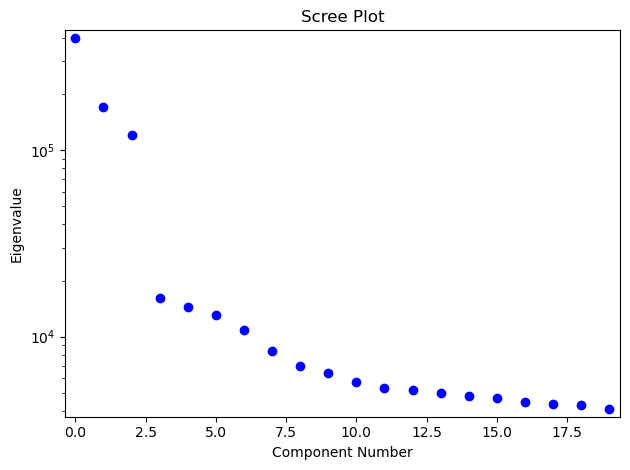

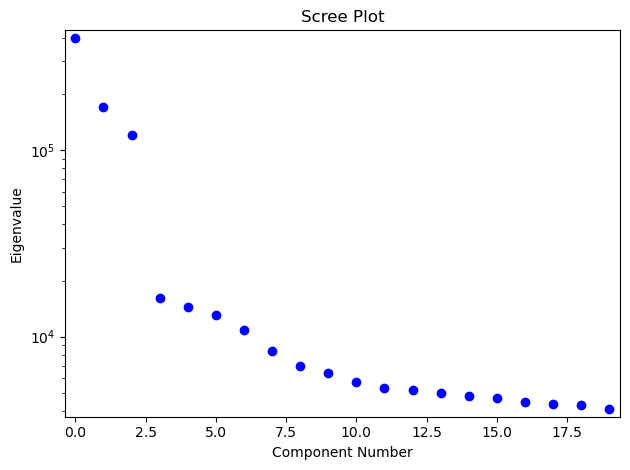

In [ ]:
sm.PCA(Y, ncomp=20).plot_scree()

## Tracy-Widom test


In [ ]:
#| hide
@njit
def _TracyWidom_statistic(
    eigenvalues: np.ndarray, # Array of eigenvalues
    ) -> np.ndarray: # Array of the Tracy-Widom statistics.
    L1 = np.cumsum(np.flip(eigenvalues))
    L1 = np.flip(L1)  # Reverse the result
    L2 = np.cumsum(np.flip(eigenvalues ** 2))
    L2 = np.flip(L2)
    N = np.arange(len(eigenvalues), 0, -1)
    S2 = (N ** 2 * L2) / (L1 ** 2)
    v = N * (N + 2) / (S2 - N)
    L = N * eigenvalues / L1
    v_st = np.where(v - 1 > 0, v - 1, np.nan)
    v_st = np.sqrt(v_st)
    N_st = np.sqrt(N)
    mu = ((v_st + N_st) ** 2) / v
    sigma = (v_st + N_st) / v * (1 / v_st + 1 / N_st) ** (1 / 3)
    twstat = (L - mu) / sigma
    return twstat

In [ ]:
#| export
TracyWidomTest = namedtuple("TracyWidomTest", "statistics pvalues")
def TracyWidom_from_eigenvalues(
        eigenvalues: np.ndarray # Array of eigenvalues
        ) -> TracyWidomTest:
    twstat = _TracyWidom_statistic(eigenvalues)
    pvalues = 1- TracyWidom(beta=1).cdf(twstat)
    return TracyWidomTest(twstat, pvalues)

In [ ]:
TracyWidom_from_eigenvalues(np.array([5, 3, 1, 0]))

TracyWidomTest(statistics=array([-0.82427304, -0.60185543, -0.55524569,         nan]), pvalues=array([0.36404483, 0.30250909, 0.29035233,        nan]))

In [ ]:
#| hide
def TracyWidom_from_matrix(
        mat: np.ndarray # Genotype matrix
        ) -> TracyWidomTest:
    eigenvalues = sm.PCA(mat).eigenvals
    return TracyWidom_from_eigenvalues(eigenvalues)

You can find the number of significant eigenvalues to choose as latent factors: 

In [ ]:
#| export
def search_latent_factors_with_TracyWidom(
        mat: np.ndarray, # Genotype matrix
        thresholds: np.ndarray # Array of significance levels
        ) -> int: # Number of significant eigenvalues
    n = len(thresholds)
    res = np.zeros(n)
    tw = TracyWidom_from_matrix(mat)
    for i in range(n):
        indices = np.where(tw.pvalues > thresholds[i])[0]
        if len(indices) > 0:
            res[i] = indices[0] - 1
    return res

In [ ]:
search_latent_factors_with_TracyWidom(Y, np.array([1e-1, 1e-3, 1e-5]))

array([15., 10., 10.])

## GEA candidates

We can use F-test based on the LFMM model to find GEA candidates:

In [ ]:
#|export
@patch
def FTest(self:RidgeLFMM,
        Y: np.ndarray, # Allele frequency matrix (nxL)
        X: np.ndarray, # Environmental matrix (nxP)
        genomic_control: bool=True, # whether to use genomic control
         ) -> np.ndarray: # Array of p-values (L) 
    "Re-fit the coefficient of the LFMM model and make an F-test."
    Y = Y - np.mean(Y, axis=0)
    X = X - np.mean(X, axis=0)
    n, d = X.shape
    U = np.hstack([np.ones((n, 1)), model.U])
    U_inv_Y = np.linalg.lstsq(U, Y, rcond=None)[0]
    res_Y = Y - U @ U_inv_Y
    res_X = X - U @ np.linalg.lstsq(U, X, rcond=None)[0]
    res_X = np.hstack([np.ones((n, 1)), res_X])
    fitted = res_X @ np.linalg.lstsq(res_X, res_Y, rcond=None)[0]
    mss = np.sum(np.abs(fitted) ** 2, axis=0)
    resvar = np.sum(np.abs(res_Y - fitted) ** 2, axis=0) / (n - d - 1)
    resvar = np.maximum(resvar, 1e-10)  # Numerical stability
    Fscores = mss / (d * resvar)
    dist = f(d, n - d - 1)   
    if genomic_control:
        gif = np.median(Fscores) / dist.ppf(0.5)
        Fscores /= gif
    pvalues = 1 - dist.cdf(Fscores)
    return np.ravel(pvalues)


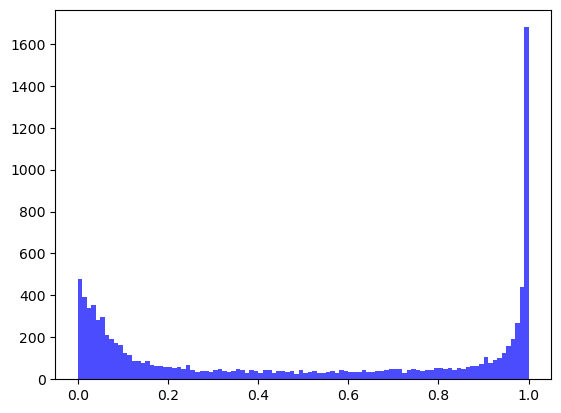

In [ ]:
fig, ax = plt.subplots()
pvalues = model.FTest(Y, X)
ax.hist(pvalues, 100, color='blue', alpha=0.7)
plt.show()

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()